# Set Up

## Mount Google Drive

Ignore if not using Google Collab:

In [1]:
from google.colab import drive

# mount google drive
drive.mount('/content/drive')
%cd /content/drive/My Drive
!git clone https://github.com/FranciscoLozCoding/cooling_with_code.git
%cd cooling_with_code
!git pull

Mounted at /content/drive
/content/drive/My Drive
fatal: destination path 'cooling_with_code' already exists and is not an empty directory.
/content/drive/MyDrive/cooling_with_code
Already up to date.


## Import Libraries

In [2]:
%%capture
%pip install shap xgboost

In [3]:
# Supress Warnings
import warnings
warnings.filterwarnings('ignore')

#data science
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import r2_score
from sklearn.feature_selection import RFECV
import shap
from sklearn.model_selection import GridSearchCV
from PIL import Image

#other
import os
import pickle

#custom tools
from tools.environment import VALID_SPLIT, RANDOM_STATE
from tools.preprocess import load_and_preprocess_data, preprocess_data
from tools.explainer import Explainer

## Import Datasets

In [ ]:
#load in dataset
csv_path = 'data/train/300m_buffer_dataset.csv'

# no split
X, Y, scaler = load_and_preprocess_data(csv_path, split=False)

# split
x_train, x_valid, y_train, y_valid, scaler = load_and_preprocess_data(
    csv_path, split=True,
    test_size=VALID_SPLIT, random_state=RANDOM_STATE)

Loading data from data/train/300m_buffer_dataset.csv
Loading data from data/train/300m_buffer_dataset.csv


# XgBoost Model

This notebook is for creating a XgBoost model using our 300m Buffer Dataset. We will apply what we learned in notebooks 4-6 (eg; [4](04_EDA.ipynb), [5](05_preprocessing.ipynb), [6](06_increasing_buffer_zone.ipynb)) to improve the model. For details on the train/test dataset refer to our past notebooks:
- [01_dataset_generation](01_dataset_generation.ipynb)
- [02_more_dataset_generation](02_more_dataset_generation.ipynb)

## Feature Selection

First, we will do feature selection. We now have interaction terms, so the dataset is filled with a lot of features that need to be dropped.

In [ ]:
# Ensure x_train is a DataFrame
x_train_df = pd.DataFrame(x_train, columns=X.columns)

In [ ]:
# Initialize XGBoost model
xgb_model = XGBRegressor(n_estimators=200, learning_rate=0.05,
                         max_depth=12, random_state=RANDOM_STATE, objective="reg:squarederror")

# Recursive Feature Elimination with Cross-Validation
rfe = RFECV(estimator=xgb_model, step=1, cv=5, scoring="r2", n_jobs=-1)

# Fit to training data
rfe.fit(x_train_df, y_train)

# Get selected features
selected_features = x_train_df.loc[:, rfe.support_]

# Get names of selected features
selected_feature_names = x_train_df.columns[rfe.support_]

# Print selected feature names
print("Selected Features:", list(selected_feature_names))

Selected Features: ['NDVI', 'SI', 'NDMI', 'NPCRI', 'Coastal_Aerosol', 'Building_Count', 'Total_Building_Area_m2', 'Building_Height', 'Building_Construction_Year', 'Ground_Elevation', 'Traffic_Volume', 'Building_Wind_X', 'Building_Wind_Y', 'Elevation_Wind_X', 'Elevation_Wind_Y', 'BldgHeight_Count', 'BuildingDensity_NDVI', 'Traffic_NDVI', 'Temp_BuildingDensity', 'Humidity_NDVI', 'Humidity_NDMI', 'Traffic_NDBI', 'Traffic_BuildingDensity', 'BuildingAge_Temp']


In [ ]:
# save the selected features so we don't have to run again
selected_features=['NDVI', 'SI', 'NDMI', 'NPCRI', 'Coastal_Aerosol', 'Building_Count',
                   'Total_Building_Area_m2', 'Building_Height', 'Building_Construction_Year',
                   'Ground_Elevation', 'Traffic_Volume', 'Building_Wind_X', 'Building_Wind_Y',
                   'Elevation_Wind_X', 'Elevation_Wind_Y', 'BldgHeight_Count', 'BuildingDensity_NDVI',
                   'Traffic_NDVI', 'Temp_BuildingDensity', 'Humidity_NDVI', 'Humidity_NDMI',
                   'Traffic_NDBI', 'Traffic_BuildingDensity', 'BuildingAge_Temp']

Here we see the features that were selected. These features maximized the cross-validation score. Now let's select them for our training/validation set.

>NOTE: These are different than our 300m Tuned RandomForestRegressor. This means that it is capturing different relationships.

In [ ]:
# select features
x_train_selected = pd.DataFrame(x_train, columns=x_train_df.columns)[selected_features]
x_valid_selected = pd.DataFrame(x_valid, columns=x_train_df.columns)[selected_features]

## Hyperparameter Tuning

Now we will tune the XGBRegressor hyperparemeters using `GridSearchCV`.

In [ ]:
# Define the base XGBoost model
xgb_model = XGBRegressor(objective="reg:squarederror", random_state=RANDOM_STATE)

# Define the grid of hyperparameters to search
param_grid = {
    "n_estimators": [100, 200, 300],  # Number of trees
    "learning_rate": [0.05, 0.1, 0.2],  # Step size
    "max_depth": [5, 7, 12],  # Tree depth
    "min_child_weight": [1, 3, 5],  # Minimum weight sum for leaf node
    "subsample": [0.8, 1.0],  # Fraction of samples per tree
    "colsample_bytree": [0.8, 1.0],  # Fraction of features per tree
    "gamma": [0, 0.1, 0.2],  # Minimum loss reduction for a split
    "reg_lambda": [None, 1, 10],  # L2 regularization (None = No L2)
    "reg_alpha": [None, 0, 1]  # L1 regularization (None = No L1)
}

# Initialize GridSearchCV
grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring="r2",  # Optimize for R-squared score
    cv=5,  # 5-fold cross-validation
    verbose=2,
    n_jobs=-1  # Use all available CPU cores
)

# Fit grid search to the **selected features only**
grid_search.fit(x_train_selected, y_train)

# Print the best hyperparameters and best score
print("Best Hyperparameters:", grid_search.best_params_)
print("Best R-squared Score:", grid_search.best_score_)

Fitting 5 folds for each of 8748 candidates, totalling 43740 fits
Best Hyperparameters: {'colsample_bytree': 0.8, 'gamma': 0, 'learning_rate': 0.05, 'max_depth': 12, 'min_child_weight': 5, 'n_estimators': 300, 'reg_alpha': None, 'reg_lambda': None, 'subsample': 0.8}
Best R-squared Score: 0.9488482807899755


Here we see the hyper params for the best model and the R-squared it got. Let's retrieve the best model.

In [ ]:
# best model, skip if model was already generated
model_pkl = 'models/300m_XGBRegressor/300m_XGBRegressor_model.pkl'
if not os.path.exists(model_pkl):
  best_xgb_model = grid_search.best_estimator_
else:
  with open(model_pkl, 'rb') as f:
    best_xgb_model = pickle.load(f)

## In-Sample Evaluation

In [ ]:
# Make predictions on the training data
insample_predictions = best_xgb_model.predict(x_train_selected)

# calculate R-squared score for in-sample predictions
print(f"In-Sample Evaluation:")

insample_r2 = r2_score(y_train, insample_predictions)
print(f"  300m buffer zone R-squared: {insample_r2}")

In-Sample Evaluation:
  300m buffer zone R-squared: 0.9977363451435304


## Out-Sample Evaluation

In [ ]:
# Make predictions on the validation data
outsample_predictions = best_xgb_model.predict(x_valid_selected)

# calculate R-squared score for in-sample predictions
print(f"Out-Sample Evaluation:")

outsample_r2 = r2_score(y_valid, outsample_predictions)
print(f"  300m buffer zone R-squared: {outsample_r2}")

Out-Sample Evaluation:
  300m buffer zone R-squared: 0.9567974751946091


# Challenge Submission

We will now submit our `XGBRegressor` model to the challenge.
>NOTE: We can have multiple submissions.

In [ ]:
# Reading the test dataset for the submission
test_dataset = pd.read_csv('data/test/300m_buffer_test_dataset.csv')
test_dataset = preprocess_data(test_dataset)

# Remove lat and lon, for now will be combined with predicted UHI later for submission
lon = test_dataset['Longitude'].values
lat = test_dataset['Latitude'].values
test_dataset = test_dataset.drop(columns=['Longitude', 'Latitude'])

# Feature Scaling
scaled = scaler.transform(test_dataset)
test_dataset = pd.DataFrame(scaled, columns=test_dataset.columns)

# select features
x_test = test_dataset[selected_features].values

# Model prediction
test_predictions = best_xgb_model.predict(x_test)

# combine predictions with lat and lon
submission_df = pd.DataFrame({
    'Longitude': lon,
    'Latitude': lat,
    'UHI Index': test_predictions
})
submission_df

,Longitude,Latitude,UHI Index
0,-73.971665,40.788763,0.967587
1,-73.971928,40.788875,0.967306
2,-73.967080,40.789080,0.960687
3,-73.972550,40.789082,0.961383
4,-73.969697,40.787953,0.959740
...,...,...,...
1035,-73.919388,40.813803,1.037774
1036,-73.931033,40.833178,1.038767
1037,-73.934647,40.854542,1.037568
1038,-73.917223,40.815413,1.038068


Save the submission dataframe to submit into challenge portal:

In [ ]:
submission_df.to_csv("300m_XGBRegressor_model_submission.csv", index=False)

Score We Received:

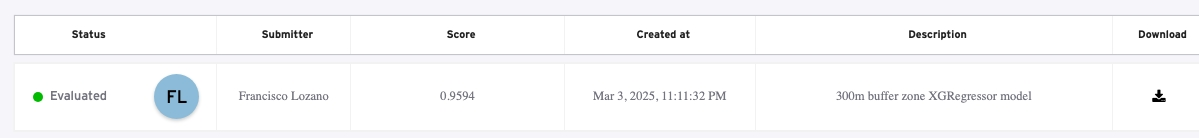

In [4]:
Image.open('images/300m_XGBRegressor_score.jpeg')

Our 300m XGBRegressor did slightly worse than our 300m tuned RandomForestRegressor.

# Understanding the Results

Now we will use SHAP to understand the results. SHAP can show us feature importance, ranking, understand feature vs. prediction relationships, and can even explain individual predictions. This is what we need to understand the drivers of the Urban Heat Island phenomenon.

In [ ]:
# create x_test_df
x_test_df = test_dataset[selected_features]

# Initialize SHAP Explainer for Random Forest Model
explainer = Explainer(
    model=best_xgb_model,
    explainer_type=shap.TreeExplainer,
    X=x_test_df,
    feature_names=x_test_df.columns
)

## Summary Plot

Here, we will see the most important features and how do features impact predictions. This is how to interpret the plot:

- Each **dot** represents a single data point from our dataset.
- **X-Axis (`SHAP Value`)**: The **impact** of a feature on the prediction.
- **Y-Axis (Feature Names)**: The **most important features** ranked from top to bottom.
- **Color (Red to Blue)**: The **feature value** (High = Red, Low = Blue).
  - **Red** = High feature value.
  - **Blue** = Low feature value.

1. **Feature Importance**  
   - Features are **ranked by importance** (most important at the top).
   - The **wider** the spread on the X-axis, the more that feature **influences predictions**.

2. **Direction of Influence**  
   - **Positive SHAP values (Right Side)**: Feature **increases** the prediction.
   - **Negative SHAP values (Left Side)**: Feature **decreases** the prediction.

3. **Effect of Feature Value (Color Gradient)**  
   - **Red (High Value)** trends to the **right**? High values **increase** predictions.
   - **Blue (Low Value)** trends to the **left**? Low values **decrease** predictions.

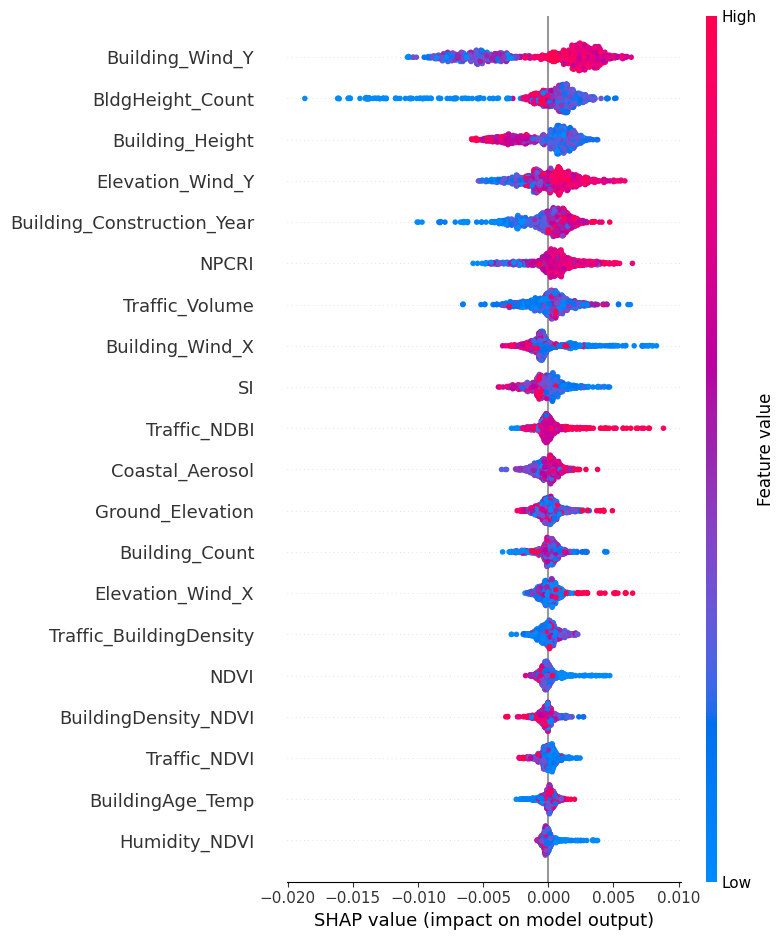

In [ ]:
explainer.summary_plot()

The SHAP summary plot provides insights into how different features influence the **Urban Heat Island (UHI) Index**. The **most impactful feature** is **`Building_Wind_Y`**, indicating that wind flow in the **Y direction** significantly affects UHI, likely due to wind-blocking effects or heat dispersion patterns around buildings. Similarly, **`BldgHeight_Count`** and **`Building_Height`** are highly influential, suggesting that **taller and denser buildings contribute strongly to heat retention or dissipation** depending on urban morphology.

Other key contributors include **`Elevation_Wind_Y`** and **`Building_Construction_Year`**, where older buildings appear to **lower UHI**, possibly due to different materials or ventilation structures compared to modern, denser developments. **Traffic-related variables** such as **`Traffic_Volume`** and **`Traffic_NDBI`** also play a significant role, reinforcing the connection between **urban activity and heat accumulation**.

Among environmental factors, **`NDVI` and `BuildingDensity_NDVI`** show that **higher vegetation density** helps **mitigate UHI effects**, as seen by their negative SHAP values for higher feature values (red points moving left). Additionally, **`Coastal_Aerosol`** and **`Ground_Elevation`** appear as moderate influencers, indicating that **air pollution and terrain height impact heat retention patterns**.

Overall, the model emphasizes **urban structure (buildings and wind interactions)** as the primary driver of UHI, followed by **traffic intensity and vegetation cover** as key mitigating or exacerbating factors. Future optimization could focus on **fine-tuning urban wind channels, increasing vegetation coverage, and managing traffic-related emissions** to reduce heat accumulation in high-risk areas.

## Bar Plot

Now, we will see overall feature importance rankings.

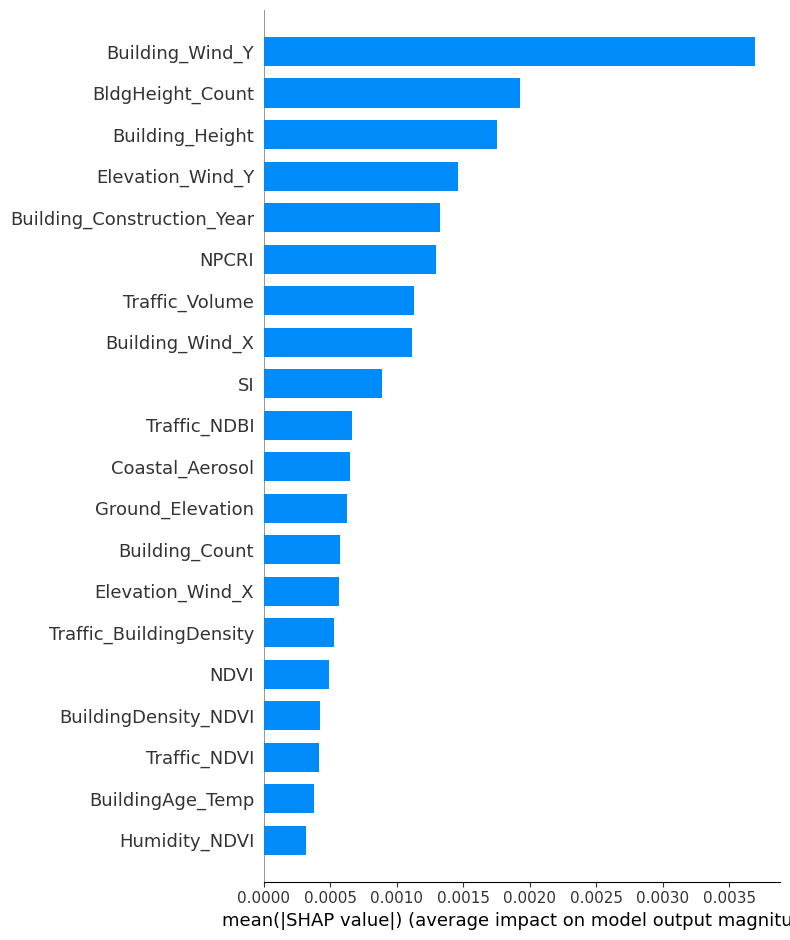

In [ ]:
explainer.bar_plot()

The SHAP bar plot highlights the **average impact** of each feature on the **XGBoost Regressor model’s predictions** for **Urban Heat Island (UHI) Index**. **`Building_Wind_Y`** is the most influential feature, indicating that the **interaction between building structures and wind flow in the Y direction** plays a crucial role in UHI formation. This suggests that certain wind patterns, potentially obstructed or redirected by tall buildings, significantly affect heat retention.

Following this, **`BldgHeight_Count`** and **`Building_Height`** rank highly, reinforcing the idea that **taller and more numerous buildings contribute to heat retention**, possibly by trapping heat within urban canyons. **`Elevation_Wind_Y`** also emerges as a key factor, indicating that **elevation changes in conjunction with wind direction** impact how heat is dispersed or retained in urban areas.

Infrastructure-related features such as **`Building_Construction_Year`** and **`Traffic_Volume`** further suggest that **older buildings may have better natural cooling properties**, while increased **traffic contributes to higher UHI levels** through emissions and pavement heat absorption. **Environmental factors** like **`NDVI` (vegetation index) and `Coastal_Aerosol`** have lower but still notable influence, indicating that **vegetation helps mitigate UHI effects**, while **airborne particles from coastal regions** might alter temperature patterns.

Overall, the model indicates that **urban structure, wind flow, and traffic density** are the dominant factors influencing UHI, while **natural elements like vegetation and elevation play a smaller but meaningful role**. Future mitigation efforts should focus on **optimizing wind corridors, promoting green infrastructure, and managing traffic emissions** to reduce heat accumulation in dense urban areas.

## Dependence Plot

Next, we will understand feature vs. prediction relationships. We can do this one by one for all features, but for now we will do Building_Height.

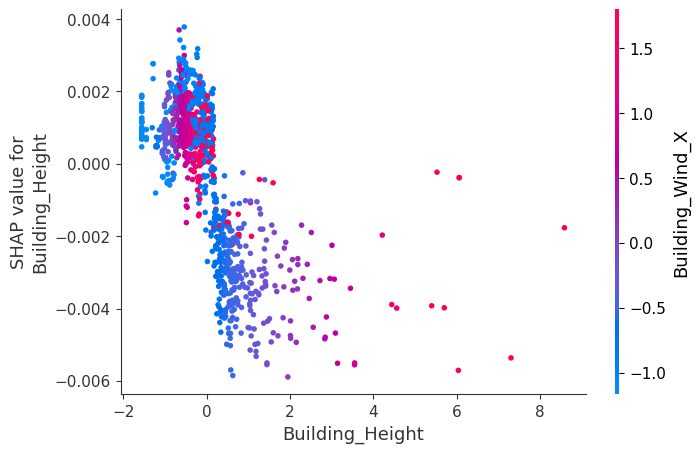

In [ ]:
explainer.dependence_plot("Building_Height")

The SHAP dependence plot for **`Building_Height`** illustrates its impact on the **Urban Heat Island (UHI) Index** predictions in your XGBoost model. The **x-axis** represents the height of buildings, while the **y-axis** shows the SHAP values, indicating whether **`Building_Height`** increases or decreases the predicted UHI. The **color gradient** corresponds to **`Building_Wind_X`**, revealing how wind interactions influence this relationship.

### **Key Insights:**
1. **Inverse Relationship Between Building Height and UHI Contribution**  
   - At **low building heights (near 0)**, SHAP values are **centered around zero**, suggesting **minimal impact** on UHI.
   - As **building height increases**, SHAP values **become more negative**, indicating that **taller buildings help reduce UHI** in some cases. This could be due to **increased shading, improved air circulation, or different construction materials**.

2. **Influence of Wind Interactions (`Building_Wind_X`)**  
   - **Blue dots (negative wind values)** show that **when wind is directed in the negative X direction**, building height has a **strong cooling effect** (lower SHAP values).
   - **Red/purple dots (positive wind values)** suggest that **when wind is directed in the positive X direction, the impact is more scattered**. This could indicate that in some cases, **wind-aligned buildings increase ventilation and heat dispersion, while in other cases, they contribute to heat retention depending on urban layout**.

3. **Outliers at Higher Building Heights**  
   - There are **a few extreme values (Building_Height > 6)** where SHAP values spike slightly higher, suggesting **exceptions where taller buildings may contribute to warming**. These could be due to **specific urban settings where heat is trapped despite increased height**.

## Force Plot

Finally, we will explain an individual prediction. We can do this one by one for all predictions, but for now we will do the first one.

In [ ]:
#show location
submission_df.iloc[0, :]

,0
Longitude,-73.971665
Latitude,40.788763
UHI Index,0.967587


In [ ]:
explainer.init_js()
explainer.force_plot(index=0)

In the **`force_plot`**, we can see which features influenced the predicted **UHI value** for the first row of the test dataset, corresponding to the location **(-73.971665, 40.788763)**. The most influential factors were **`Building_Wind_Y`** and **`Building_Construction_Year`**. **`Building_Wind_Y`** pushed the prediction **higher**, while **`Building_Construction_Year`** pulled it **lower**.

Other features also contributed to reducing the **UHI prediction**, including **`Elevation_Wind_Y`**, which further lowered the value. Since the final **predicted UHI value is 0.97**, this suggests that the location is **relatively cool**, benefiting from multiple features that help **reduce urban heat retention**. Additionally, although **`Building_Wind_Y`** had an increasing effect, its overall influence was minor, meaning it does not significantly contribute to warming at this location.

# Summary Table

In [ ]:
# create the summary table
models = ['300m_XGBRegressor_model']

data = {
    'Model': models,
    'Training R-squared': [insample_r2],
    'Validation R-squared': [outsample_r2]
}

summary_df = pd.DataFrame(data)
summary_df

,Model,Training R-squared,Validation R-squared
0,300m_XGBRegressor_model,0.997736,0.956797


# Save The Model

In [ ]:
# Save the model and scaler to files
with open('300m_XGBRegressor_model.pkl', 'wb') as f:
    pickle.dump(best_xgb_model, f)
with open('300m_standard_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Conclusion

To conclude, the **300m `XGBRegressor`** performed well, demonstrating a strong ability to model and predict **Urban Heat Island (UHI) effects**. The model effectively captured **complex relationships** between urban morphology, environmental factors, and climatic variables, showcasing its capability to handle **non-linear interactions** and **feature dependencies**. Although, it did not do better than our **tuned 300m `RandomForestRegressor`**.